In [1]:
import matplotlib.pyplot as plt
import numpy as np

from StatTools.filters.kalman_filter import KalmanFilter
from StatTools.generators.kasdin_generator import ERKasdinGenerator
from StatTools.experimental.augmentation.perturbations import add_noise

from visualization_toolkit.styles.line import line_empty_marker, line_markers

In [2]:
np.random.seed(42)
ho = 0.8 # Hurst
observation_len = 2**10

In [3]:
generator = ERKasdinGenerator(ho, length=observation_len)
generated_signal = generator.get_full_sequence()
noisy_signal, noise = add_noise(generated_signal, 0.3)

# Model signal for evaluating Q matrix
model_generator = ERKasdinGenerator(ho, length=observation_len)
model_signal = model_generator.get_full_sequence()

recovered_signal = np.zeros(observation_len)

In [4]:
kf = KalmanFilter(
    dim_x=2,
    dim_z=1,
    F=np.array([[1, 1], [0, 1]]),
    H=np.array([[1, 0]]),
    R=np.array([[np.var(noise)]]),
    Q=np.array([[np.var(model_signal), 0], [0, np.var(np.diff(model_signal))]]),
)

In [5]:
for k in range(observation_len):
    kf.predict()
    kf.adjust(np.array([[noisy_signal[k]]]))
    recovered_signal[k] = kf.get_current_measurement().item()

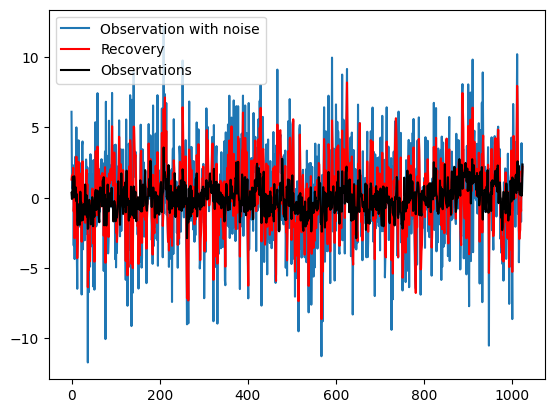

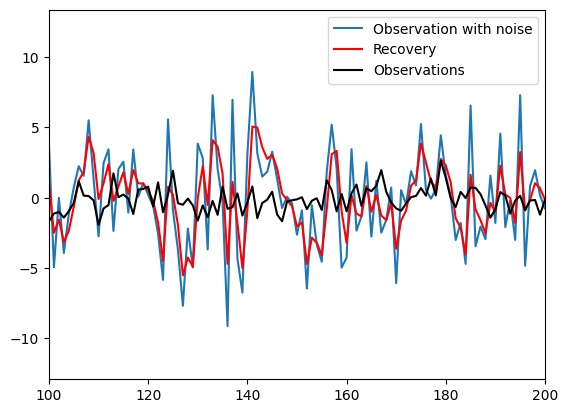

In [6]:
plt.plot(noisy_signal, label="Observation with noise")
plt.plot(recovered_signal, "r", label="Recovery")
plt.plot(generated_signal, "k", label="Observations")
plt.legend()
plt.show()

plt.plot(noisy_signal, label="Observation with noise")
plt.plot(recovered_signal, "r", label="Recovery")
plt.plot(generated_signal, "k", label="Observations")
plt.xlim(100, 200)
plt.legend()
plt.show()

In [7]:
def get_rmse(signal_a, signal_b, is_mean=True):
    assert len(signal_a) == len(signal_b), "Signals must have the same length."

    if is_mean:
        mse = np.mean((signal_a - signal_b) ** 2)
        return np.sqrt(mse)
    mse = (signal_a - signal_b) ** 2
    return np.sqrt(mse)


Mean RMSE:
Recovery 1.89
Noisy 2.64


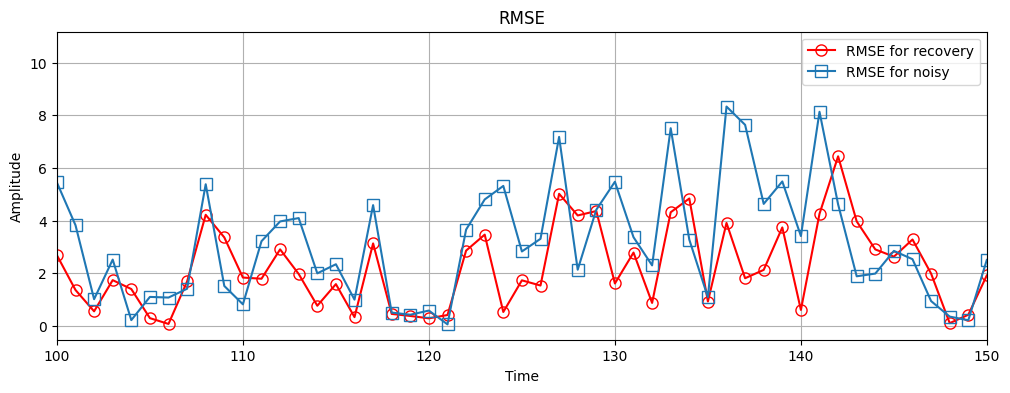

In [8]:
plt.figure(figsize=(12, 4))

signal = get_rmse(generated_signal, recovered_signal, False)
plt.plot(
    signal,
    **line_empty_marker(marker=line_markers[0], color="r"),
    label="RMSE for recovery",
)
print(f"Mean RMSE:\nRecovery {np.mean(signal):.2f}")
signal = get_rmse(generated_signal, noisy_signal, False)
plt.plot(
    signal,
    **line_empty_marker(marker=line_markers[1], color="tab:blue"),
    label="RMSE for noisy",
)
print(f"Noisy {np.mean(signal):.2f}")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.xlim(100, 150)
plt.legend()
plt.title("RMSE")
plt.grid(True)
plt.show()